In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("/content/EDA-IPL/data/matches.csv")
df.head()

,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


In [4]:
df["toss_win_match_win"] = df["toss_winner"] == df["winner"]

toss_win_pct = df["toss_win_match_win"].mean() * 100
print("Win % when team wins toss:", toss_win_pct)

Win % when team wins toss: 50.593607305936075


In [5]:
decision_win = df.groupby("toss_decision")["toss_win_match_win"].mean() * 100
decision_win

,toss_win_match_win
toss_decision,
bat,45.268542
field,53.551136


In [6]:
season_trend = df.groupby(["season", "toss_decision"])["toss_win_match_win"].mean().reset_index()

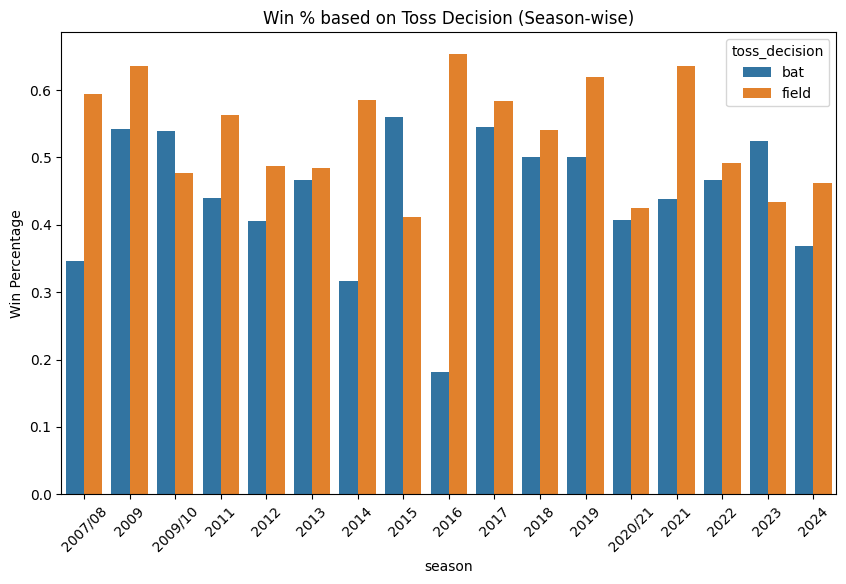

In [7]:
plt.figure(figsize=(10,6))
sns.barplot(data=season_trend, x="season", y="toss_win_match_win", hue="toss_decision")

plt.title("Win % based on Toss Decision (Season-wise)")
plt.ylabel("Win Percentage")
plt.xticks(rotation=45)

plt.show()

## Summary of Findings

- Teams that win the toss win approximately 50.6% of matches, indicating that the toss provides only a very slight advantage and does not strongly influence match outcomes.

- When analyzing toss decisions:
  - Teams choosing to field first have a higher win percentage (~53.5%)
  - Teams choosing to bat first have a lower win percentage (~45.3%)

- The season-wise trend shows that in most seasons, teams that chose to field first performed better than those who chose to bat first.

- In recent seasons as well, the advantage of fielding first continues to be slightly higher, suggesting that chasing targets is generally more favorable in modern IPL matches.

- Overall verdict: Toss alone does not guarantee victory, but choosing to field first provides a consistent strategic advantage across seasons.